In [1]:
# Parameters
name = "TEST"
fits_path = ""

In [2]:
# Parameters
name = "fake_cube_mod_finite_noise_sigE2_m355_r8_N128"
fits_path = "fits_ready/fake_cube_mod_finite_noise_sigE2_m355_r8_N128.fits"


In [3]:
import time
start_time=time.time()

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult


# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

import strucfunc                   
import fit_structure_function
import ci_results_compiler
import bfunc
import bplot

# Velocity Field

In [5]:
from pathlib import Path
assert fits_path, "fits_path is empty (parameter injection failed)"
assert Path(fits_path).exists(), f"Missing FITS file: {fits_path}"
hdul = fits.open(fits_path)

In [6]:
# Loading 3D fake maps
#hdul = fits.open(name + '.fits')
hdr = hdul[0].header
print(hdul.info())
print(hdr)
sb = hdul['MOM0'].data.astype(float)
vv= hdul['MOM1'].data.astype(float)

Filename: fits_ready/fake_cube_mod_finite_noise_sigE2_m355_r8_N128.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  MOM0          1 ImageHDU         8   (128, 128)   float64   
  2  MOM1          1 ImageHDU         8   (128, 128)   float64   


None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'J. Garcia-Vazquez'  / File creator                                   M3D     =                 0.55 / k = 3 + m3D                                    RA      =                  8.0 / Artificial correlation length                  SIG     =  0.36691492527294983 / Standard deviation vel artificial map          SIG2    =  0.13462656238805437 / Vel Variance artificial map                    S0      =                    0 / Atmospheric seeing                             NOISE   =                    0 / Instrumental noise                             BOX_SIZE=                  128 / Observational box_size                         PC      =                    1 / pa

In [7]:
m3D      = hdul[0].header['M3D']
ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_16380\3883748132.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 1.0, 'Moment 0')

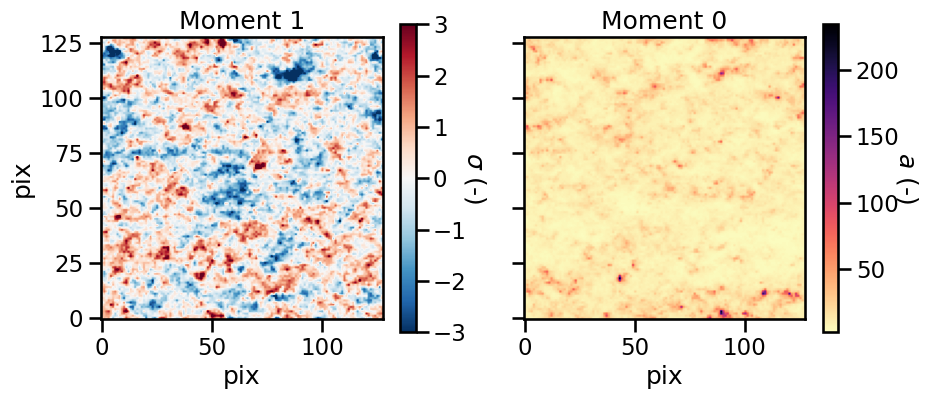

In [8]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma_r")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")
ax.set_title("Moment 1")
axx.set_title("Moment 0")

# Structure function

In [9]:
Br = strucfunc.strucfunc_numba_parallel(vv, wmap=sb, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\pipeline_VIENTO\pipeline_template_test\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\pipeline_VIENTO\pipeline_template_test\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


In [10]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)

In [11]:
# Export results from Numba structure function
data_export = {
    'strucfun_numba_parallel' : Br,
}

jsonfilename = "results_Br/" + name +".json"
with open(jsonfilename, "w") as f:
    json.dump(data_export, fp=f, indent=3, cls=MyEncoder)

In [12]:
B  = Br['Unweighted B(r)']
Bw = Br['Unweighted B(r)']
r  = 10**np.array(Br['log10 r'])

# Fit and Confidence intervals

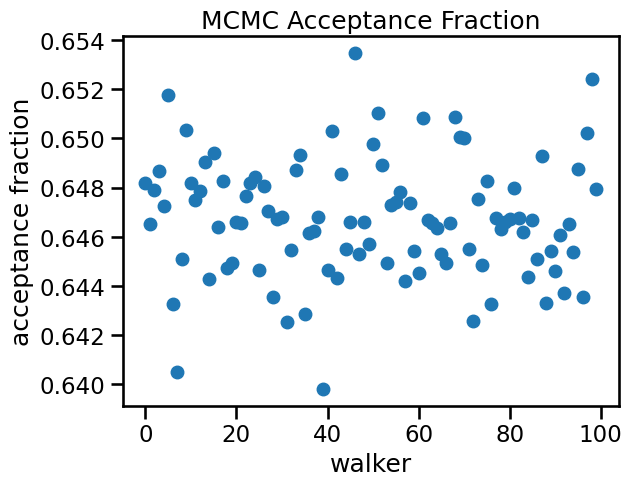

Autocorrelation time for the parameters:
----------------------------------------
r0 = 38.790
sig2 = 38.626
m = 38.580


In [13]:
fit_Br = fit_structure_function.fit_structure_function_ideal(Br, box_size, bfunc, name = name, data = name)

In [14]:
save_modelresult(fit_Br['result'], "results_fit/" + name + "result_ideal.sav")
save_modelresult(fit_Br['result_emcee'], "results_fit/" + name + "result_emcee_ideal.sav")

In [15]:
params_Br = ci_results_compiler.ci_results_compiler_ideal(fit_Br)
params_Br

{'sig2': [0.984371365758298, 0.03638714837306267, 0.03398159107572929],
 'r0': [2.2658527171296696, 0.22694269256817057, 0.19279157807987968],
 'm': [1.0403739592017445, 0.13021544956980624, 0.11616430639273412]}

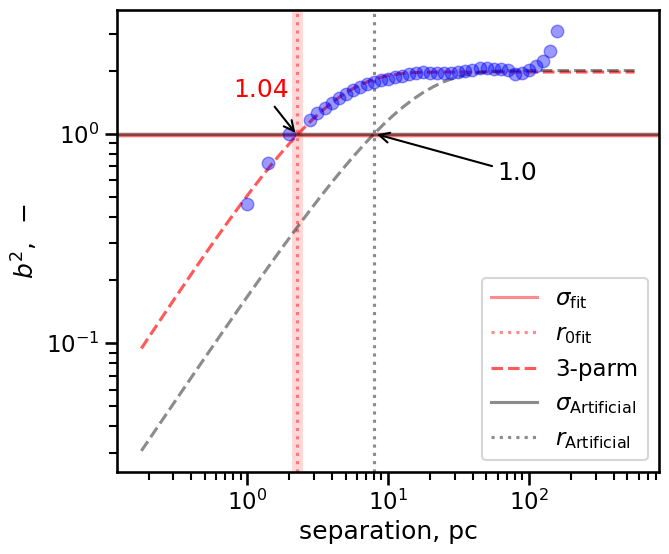

In [16]:
m_obs    = 1.0
sig2norm = 1.0

rgrid = np.logspace(-0.75, 2.75)


fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(10**np.array(Br['log10 r']), Br['Unweighted B(r)'], fmt='o', alpha=0.4,color="blue")

# Sigma**2
ax.axhspan(params_Br['sig2'][0]-params_Br['sig2'][2],params_Br['sig2'][0]+ params_Br['sig2'][1], facecolor='red', alpha=0.15)
ax.axhline(params_Br['sig2'][0], ls='-', color="red", alpha = 0.45, label = r'$\sigma_\text{fit}$',)

# r0
ax.axvspan(params_Br['r0'][0]-params_Br['r0'][2],params_Br['r0'][0]+ params_Br['r0'][1], facecolor='red', alpha=0.15)
ax.axvline(params_Br['r0'][0], ls=':', color="red", alpha = 0.45, label = r'$r_{0\text{fit}}$',)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, params_Br['r0'][0], params_Br['sig2'][0], params_Br['m'][0]), color="red", alpha = 0.65, ls='--', label = '3-parm')

# Power spectra
ax.axhline(sig2norm, ls='-', label = r'$\sigma_\text{Artificial}$', color="black", alpha = 0.45)
ax.axvline(ra, ls=':', label = r'$r_\text{Artificial}$', color="black", alpha = 0.45)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, ra, sig2norm, m_obs ), color="black", alpha = 0.45, ls='--')

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
#       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
       ylabel=r'$b^2,\ -$'
      )


ax.annotate(
    str(m_obs),           # text
    xy=(ra, sig2norm),            
    xytext=(60, 0.6),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->")  # arrow style
)

ax.annotate(
    str(round(params_Br['m'][0],2)),           # text
    xy=(params_Br['r0'][0], params_Br['sig2'][0]),            
    xytext=(0.8, 1.5),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->"),  # arrow style
    color = "red"
)


ax.legend()


None

In [17]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 450.162556886673 seconds ---
